In [ ]:
# Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


import time
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut
import time
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut, GeocoderRateLimited
from tqdm import tqdm
import os

import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('..')

from config.config import KENYA_FACILITIES_FILE

# Loading dataset
df = pd.read_excel(KENYA_FACILITIES_FILE, engine='xlrd')

# Basic overview
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
Shape: (10505, 50)

Columns:
 ['Facility Code', 'Facility Name', 'Province', 'County', 'District', 'Division', 'Type', 'Owner', 'Location', 'Sub Location', 'Description of Location', 'Constituency', 'Nearest Town', 'Beds', 'Cots', 'Official Landline', 'Official Fax', 'Official Mobile', 'Official Email', 'Official Address', 'Official Alternate No', 'Town', 'Post Code', 'In Charge', 'Job Title of in Charge', 'Open 24 Hours', 'Open Weekends', 'Operational Status', 'ANC', 'ART', 'BEOC', 'BLOOD', 'CAES SEC', 'CEOC', 'C-IMCI', 'EPI', 'FP', 'GROWM', 'HBC', 'HCT', 'IPD', 'OPD', 'OUTREACH', 'PMTCT', 'RAD/XRAY', 'RHTC/RHDC', 'TB DIAG', 'TB LABS', 'TB TREAT', 'YOUTH']

First 5 rows:


,Facility Code,Facility Name,Province,County,District,Division,Type,Owner,Location,Sub Location,...,IPD,OPD,OUTREACH,PMTCT,RAD/XRAY,RHTC/RHDC,TB DIAG,TB LABS,TB TREAT,YOUTH
0,19224,CDF Kiriari Dispensary,Eastern,Embu,Manyatta,Manyatta,Dispensary,Ministry of Health,Ruguru,Ruguru,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,19310,St Jude's Huruma Community Health Services,Nairobi,Nairobi,Mathare,Huruma,Medical Clinic,Private Practice - Unspecified,Huruma,Huruma,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,14180,10 Engineer VCT,Rift Valley,Laikipia,Laikipia East,Central,Dispensary,Armed Forces,Nanyuki,Majengo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,17486,12 Engineers,Central,Kiambu,Thika West,NaN,Dispensary,Ministry of Health,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,18393,3Kl Maternity & Nursing Home,Rift Valley,Kajiado,Kajiado North,Ongata Rongai,Nursing Home,Private Practice - Clinical Officer,Gataka,Gataka,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
# Basic data quality check
print("Missing values per column:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)
print("\nOperational Status values:")
print(df['Operational Status'].value_counts())
print("\nFacility Type values:")
print(df['Type'].value_counts())
print("\nOwner values:")
print(df['Owner'].value_counts())

Missing values per column:
Facility Code                  0
Facility Name                  0
Province                       0
County                         0
District                       0
Division                     267
Type                           0
Owner                          0
Location                     495
Sub Location                 892
Description of Location     5201
Constituency                   0
Nearest Town                 602
Beds                          87
Cots                          77
Official Landline           9138
Official Fax                9965
Official Mobile             7590
Official Email              8648
Official Address            3458
Official Alternate No       9553
Town                        2667
Post Code                   3825
In Charge                   2140
Job Title of in Charge      3099
Open 24 Hours                447
Open Weekends                457
Operational Status             0
ANC                        10505
ART             

In [ ]:
# Filtering  to operational facilities only
df_operational = df[df['Operational Status'] == 'Operational'].copy()
print("Operational facilities:", len(df_operational))

# Defining oncology-capable facility types
oncology_types = [
    'National Referral Hospital',
    'Provincial General Hospital', 
    'District Hospital',
    'Sub-District Hospital',
    'Medical Centre'
]

# Filtering oncology-capable facilities
df_oncology = df_operational[
    df_operational['Type'].isin(oncology_types)
].copy()

print("Oncology-capable facilities:", len(df_oncology))
print("\nBreakdown by type:")
print(df_oncology['Type'].value_counts())
print("\nBreakdown by County (top 20):")
print(df_oncology['County'].value_counts().head(20))

Operational facilities: 9551
Oncology-capable facilities: 331

Breakdown by type:
Type
Sub-District Hospital          142
District Hospital              141
Medical Centre                  36
Provincial General Hospital      9
National Referral Hospital       3
Name: count, dtype: int64

Breakdown by County (top 20):
County
Nairobi            18
Meru               18
Homa Bay           15
Kisii              15
Kakamega           12
Kisumu             12
Kitui              12
Makueni            11
Wajir              11
Kiambu             10
Bungoma            10
Nakuru             10
Migori             10
Garissa             9
Nyamira             8
Murang'a            8
Siaya               7
Kericho             7
Elgeyo Marakwet     7
Machakos            6
Name: count, dtype: int64


In [ ]:
# Initializing geocoder
geolocator = Nominatim(user_agent="cancerpath_africa")

def geocode_facility(row):
    """Geocode a facility using its name and county"""
    try:
        query = f"{row['Facility Name']}, {row['County']}, Kenya"
        location = geolocator.geocode(query, timeout=10)
        if location:
            return pd.Series([location.latitude, location.longitude])
        else:
            # Fall back to county level
            query = f"{row['County']} County, Kenya"
            location = geolocator.geocode(query, timeout=10)
            if location:
                return pd.Series([location.latitude, location.longitude])
        return pd.Series([None, None])
    except GeocoderTimedOut:
        return pd.Series([None, None])

# Test geocoding on first 5 facilities first
print("Testing geocoding on 5 facilities...")
test_df = df_oncology.head(5).copy()
test_df[['Latitude', 'Longitude']] = test_df.apply(geocode_facility, axis=1)
print(test_df[['Facility Name', 'County', 'Latitude', 'Longitude']])

Testing geocoding on 5 facilities...
                       Facility Name         County  Latitude  Longitude
66       Alupe Sub-District Hospital          Busia  0.371205  34.264795
98      Awendo Sub-District Hospital         Migori -1.019224  34.309543
99     Baragoi Sub-District Hospital        Samburu  0.867391  36.806382
114  Baraka Medical Clinic (Mbitini)          Kitui -1.564222  38.372812
252        Tharaka District Hospital  Tharaka Nithi       NaN        NaN


In [ ]:
geolocator = Nominatim(user_agent="cancerpath_africa_v3")

CHECKPOINT_PATH = '../data/processed/geocoding_checkpoint.csv'

def geocode_facility(row):
    time.sleep(1.2)
    try:
        query = f"{row['Facility Name']}, {row['County']}, Kenya"
        location = geolocator.geocode(query, timeout=10)
        if location:
            return location.latitude, location.longitude
        time.sleep(1.2)
        query = f"{row['County']} County, Kenya"
        location = geolocator.geocode(query, timeout=10)
        if location:
            return location.latitude, location.longitude
        return None, None
    except (GeocoderTimedOut, GeocoderRateLimited):
        time.sleep(5)
        return None, None

# Resuming from checkpoint if exists
if os.path.exists(CHECKPOINT_PATH):
    df_checkpoint = pd.read_csv(CHECKPOINT_PATH)
    completed_codes = set(df_checkpoint['Facility Code'].tolist())
    df_remaining = df_oncology[
        ~df_oncology['Facility Code'].isin(completed_codes)
    ].copy()
    print(f"Resuming from checkpoint: {len(completed_codes)} done, {len(df_remaining)} remaining")
else:
    df_checkpoint = pd.DataFrame()
    df_remaining = df_oncology.copy()
    print(f"Starting fresh: {len(df_remaining)} facilities to geocode")

# Geocoding with checkpointing every 50 rows
results = []
for i, (idx, row) in enumerate(tqdm(df_remaining.iterrows(), 
                                     total=len(df_remaining))):
    lat, lon = geocode_facility(row)
    row['Latitude'] = lat
    row['Longitude'] = lon
    results.append(row)

    # Saving checkpoint every 50 rows
    if (i + 1) % 50 == 0:
        df_so_far = pd.DataFrame(results)
        df_combined = pd.concat([df_checkpoint, df_so_far], ignore_index=True)
        df_combined.to_csv(CHECKPOINT_PATH, index=False)
        print(f"\nCheckpoint saved at {i + 1} rows")

# Final save
df_final = pd.DataFrame(results)
df_combined = pd.concat([df_checkpoint, df_final], ignore_index=True)
df_combined.to_csv(CHECKPOINT_PATH, index=False)
df_combined.to_csv('../data/processed/kenya_oncology_facilities.csv', index=False)

print(f"\nGeocoding complete!")
print(f"Successfully geocoded: {df_combined['Latitude'].notna().sum()}/{len(df_combined)}")
print(f"Saved to data/processed/kenya_oncology_facilities.csv")

Resuming from checkpoint: 331 done, 0 remaining


0it [00:00, ?it/s]


Geocoding complete!
Successfully geocoded: 327/331
Saved to data/processed/kenya_oncology_facilities.csv


Shape: (331, 52)

Geocoding coverage:
With coordinates: 327
Missing coordinates: 4

Sample of geocoded facilities:
                             Facility Name           County  \
0              Alupe Sub-District Hospital            Busia   
1             Awendo Sub-District Hospital           Migori   
2            Baragoi Sub-District Hospital          Samburu   
3          Baraka Medical Clinic (Mbitini)            Kitui   
4                Tharaka District Hospital    Tharaka Nithi   
5  The Aga Khan University Hospital T Mall          Nairobi   
6           The Great Lakes Medical Centre           Vihiga   
7              Afya Health System Hospital         Homa Bay   
8                  Busia District Hospital            Busia   
9              Chebiemit District Hospital  Elgeyo Marakwet   

                    Type  Latitude  Longitude  
0  Sub-District Hospital  0.371205  34.264795  
1  Sub-District Hospital -1.019224  34.309543  
2  Sub-District Hospital  0.867391  36.806382  

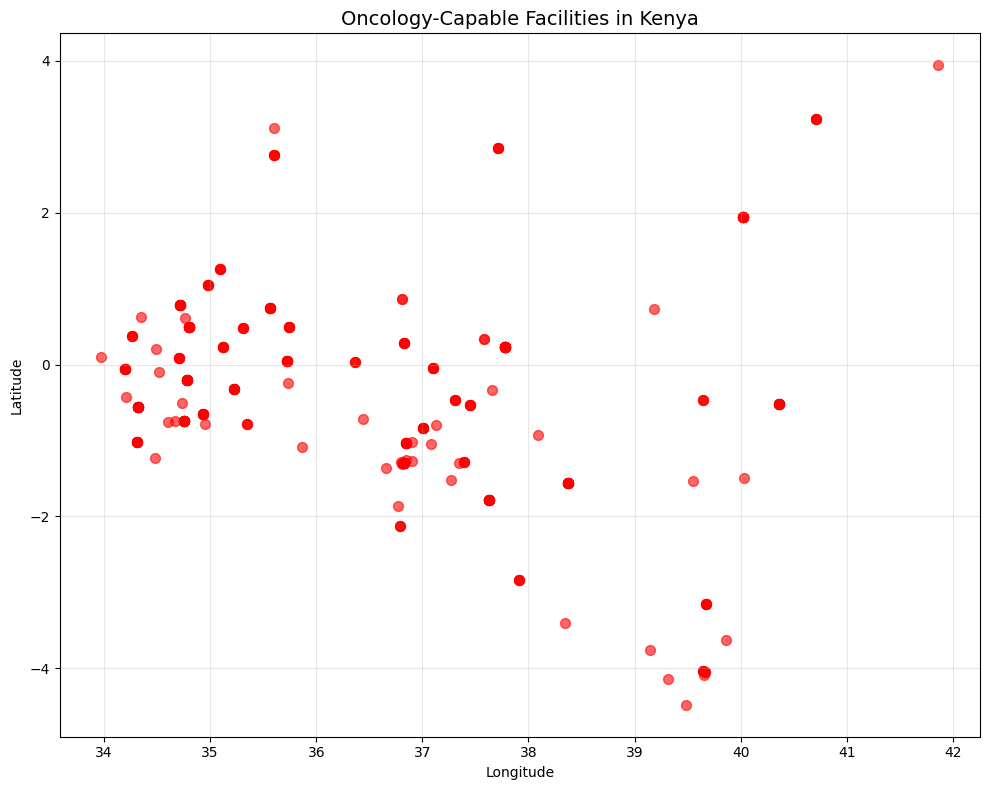


Map saved to outputs/figures/


In [ ]:
# Loading and verifying saved file
df_geo = pd.read_csv('../data/processed/kenya_oncology_facilities.csv')

print("Shape:", df_geo.shape)
print("\nGeocoding coverage:")
print(f"With coordinates: {df_geo['Latitude'].notna().sum()}")
print(f"Missing coordinates: {df_geo['Latitude'].isna().sum()}")
print("\nSample of geocoded facilities:")
print(df_geo[['Facility Name', 'County', 'Type', 'Latitude', 'Longitude']].head(10))

# Quick map visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(
    df_geo['Longitude'], 
    df_geo['Latitude'],
    c='red', alpha=0.6, s=50
)
plt.title('Oncology-Capable Facilities in Kenya', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/kenya_oncology_facilities_map.png', dpi=150)
plt.show()
print("\nMap saved to outputs/figures/")